<a href="https://colab.research.google.com/github/HY-BME/bme_test_files/blob/%EB%B0%94%EC%9D%B4%EC%98%A4%EA%B3%B5%ED%95%99%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4%EA%B8%B0%EC%88%A0/Iris%EB%B3%B5%EC%8A%B5_0315.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

iris_dataset의 키:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 
...
타깃의 이름: ['setosa' 'versicolor' 'virginica']
특성의 이름:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
data의 타입: <class 'numpy.ndarray'>
data의 크기: (150, 4)
data의 처음 다섯 행:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
target의 타입: <class 'numpy.ndarray'>
target의 크기: (150,)
타깃:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
X_train 크

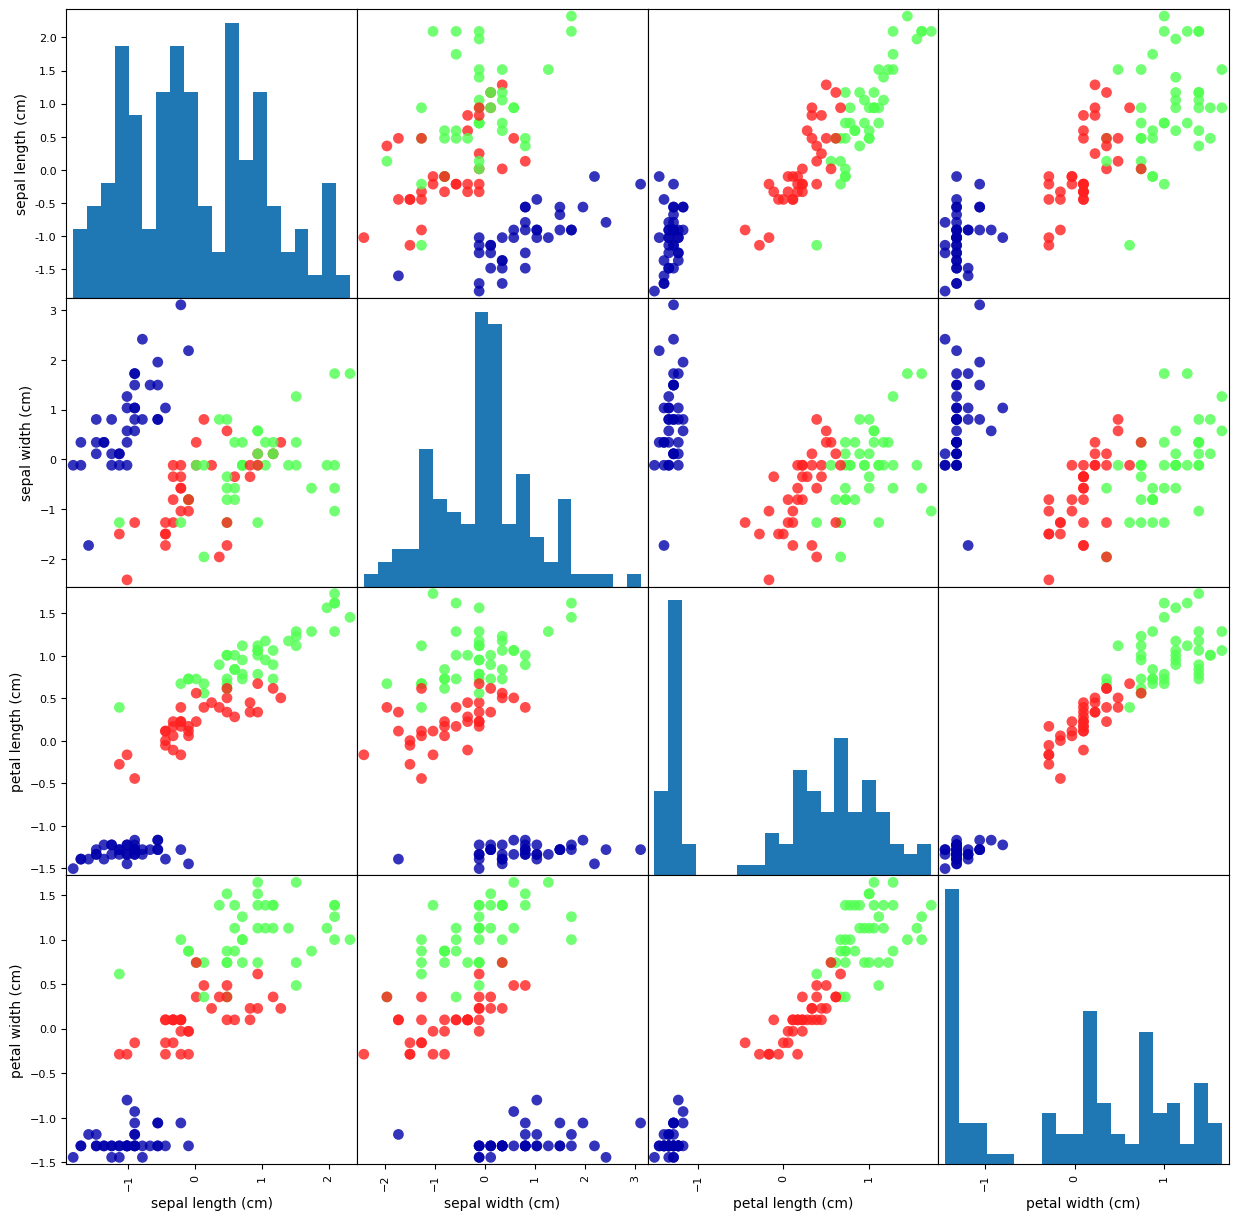

KNN 정확도: 0.9736842105263158
X_new.shape: (1, 4)
예측: [2]
예측한 타깃의 이름: ['virginica']
테스트 세트에 대한 예측값:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
테스트 세트의 정확도: 0.97
테스트 세트의 정확도: 0.97
테스트 세트의 정확도: 0.97


In [11]:
# (1) 데이터 로드
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn

iris_dataset = load_iris()
X = iris_dataset.data
y = iris_dataset.target

print("iris_dataset의 키:\n", iris_dataset.keys())

print(iris_dataset['DESCR'][:193] + "\n...")

print("타깃의 이름:", iris_dataset['target_names'])

print("특성의 이름:\n", iris_dataset['feature_names'])

print("data의 타입:", type(iris_dataset['data']))

print("data의 크기:", iris_dataset['data'].shape)

print("data의 처음 다섯 행:\n", iris_dataset['data'][:5])

print("target의 타입:", type(iris_dataset['target']))

print("target의 크기:", iris_dataset['target'].shape)

print("타깃:\n", iris_dataset['target'])

# (2) 데이터셋 분리
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'], random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)

print("X_test 크기:", X_test.shape)
print("y_test 크기:", y_test.shape)

# (3) 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 그래프 생성
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15), marker='o',
                           hist_kwds={'bins': 20}, s=60, alpha=.8, cmap = mglearn.cm3)
plt.show()

# (1) 모델 생성
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# (2) 예측
y_pred_knn = knn.predict(X_test)

# (3) 정확도 평가
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN 정확도: {accuracy_knn}')

# (4) 예측하기
X_new = np.array([[5, 2.9, 1, 0.2]])
print("X_new.shape:", X_new.shape)

prediction = knn.predict(X_new)
print("예측:", prediction)
print("예측한 타깃의 이름:",
       iris_dataset['target_names'][prediction])

# (5) 모델 평가하기
y_pred = knn.predict(X_test)
print("테스트 세트에 대한 예측값:\n", y_pred)

print("테스트 세트의 정확도: {:.2f}".format(np.mean(y_pred == y_test)))

print("테스트 세트의 정확도: {:.2f}".format(knn.score(X_test, y_test)))

X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

# fit() 함수는 모델에 학습 데이터(Training Data)를 로드하고, 새로운 데이터가 들어왔을 때 비교할 기준점(이웃)들을 저장하는 과정
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)


print("테스트 세트의 정확도: {:.2f}".format(knn.score(X_test, y_test)))

